In [23]:
import sys
import os
import importlib
import numpy as np

#Add code paths
sys.path.append(os.path.abspath("../code/part4/"))

# Ex4



In [24]:
import matplotlib.pyplot as plt
from sklearn import metrics, datasets, tree
from sklearn.model_selection import train_test_split

# 1. load 
digits = datasets.load_digits() 
X, y = digits.data, digits.target

#from sklearn.datasets import fetch_openml
#mnist = fetch_openml('mnist_784')

# partition data with train_test_split

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7,stratify=y,random_state=42)


print("train size:",len(X_train),"\ntest size:",len(X_test))

train size: 1257 
test size: 540


## Logistic Regression

In [25]:
import logistic_regression as lr
importlib.reload(lr) 

lr.train(X_train, X_test, y_train, y_test)

accuracy on testing set: 0.96


## Neural Network

### a) Indicate your best parameters of the hidden layer size and compare the results (accuracy) with the logistic regression  Indicate the loss curve of the MLPClassifier. What is your conclusion (one sentence)?

In [26]:
layer_configs = [(10,4), (15,8), (20,10), (30,15), (40,20), (50,25), (60,30), (70,35), (80,40), (90,45), (100,50)]
best_acc = 0
best_config = None
best_loss_curve = None

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy on testing set: 0.8574


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy on testing set: 0.9148


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy on testing set: 0.9463


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy on testing set: 0.9556


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy on testing set: 0.9519
accuracy on testing set: 0.9704
accuracy on testing set: 0.9759
accuracy on testing set: 0.9593
accuracy on testing set: 0.9611
accuracy on testing set: 0.9722
accuracy on testing set: 0.9685

Best NN config: (60, 30) with Accuracy = 0.9759


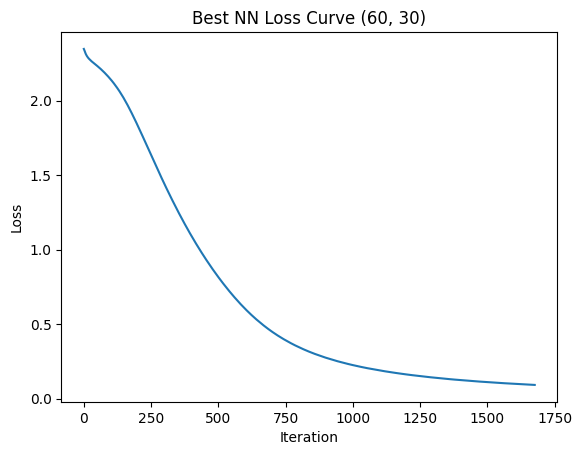

In [27]:
import neural_network as nn
importlib.reload(nn) 

for config in layer_configs:
    acc, loss_curve = nn.train(X_train, X_test, y_train, y_test, config, architecture = "logistic")
    if acc > best_acc:
        best_acc = acc
        best_config = config
        best_loss_curve = loss_curve

print(f"\nBest NN config: {best_config} with Accuracy = {best_acc:.4f}")

# Plot loss curve of the best NN
plt.plot(best_loss_curve)
plt.title(f"Best NN Loss Curve {best_config}")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

JUSTIFICATION: The best configuration for the MLP classifier was obtained with a hidden layer size of (60, 30), achieving an accuracy of 0.9759, compared to 0.96 obtained with the logistic regression model. The loss curve of the MLPClassifier shows a steady decrease and convergence after several iterations, indicating successful training without overfitting. 

The MLP model, with its additional non-linear layers, outperforms logistic regression by capturing more complex patterns in the data, leading to a modest but consistent improvement in accuracy.

### b) Using the best architecture change for the activation function ‘identity’. Is the result still better? Indicate why not to use the identity function in the hidden layer

accuracy on testing set: 0.9481


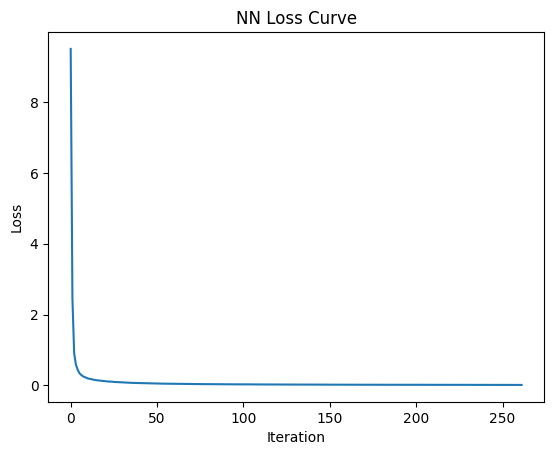

In [28]:
import neural_network as nn
importlib.reload(nn) 

_, loss_curve = nn.train(X_train, X_test, y_train, y_test, best_config, architecture = "identity")

# Plot loss curve 
plt.plot(loss_curve)
plt.title(f"NN Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

JUSTIFICATION: Using the same architecture (60, 30) but changing the activation function to ‘identity’, the accuracy decreased to 0.9481, which is lower than both the MLP with the ‘logistic’ activation (0.9759) and the logistic regression model (0.96).

The identity activation function performs a linear transformation of the inputs, meaning that all hidden layers effectively collapse into a single linear model. As a result, the network loses its ability to model non-linear relationships, which are essential for complex datasets such as the digits dataset.

Conclusion: The identity function should not be used in hidden layers because it removes the non-linearity that allows neural networks to learn complex decision boundaries, leading to poorer performance.